In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('movie_reviews')
from nltk.corpus import movie_reviews

data = []
for fileid in movie_reviews.fileids():
    category = movie_reviews.categories(fileid)[0]
    text = movie_reviews.raw(fileid)
    data.append({'text': text, 'label': category})

df = pd.DataFrame(data)
df.to_csv('movie_reviews.csv', index = False)
df

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\yusif\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.


,text,label
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg
...,...,...
1995,wow ! what a movie . \nit's everything a movie...,pos
1996,"richard gere can be a commanding actor , but h...",pos
1997,"glory--starring matthew broderick , denzel was...",pos
1998,steven spielberg's second epic film on world w...,pos


In [4]:
print(df.shape)
print(df['label'].value_counts())

(2000, 2)
label
neg    1000
pos    1000
Name: count, dtype: int64


In [5]:
# create word count with df['text']
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df

,text,label,word_count
0,"plot : two teen couples go to a church party ,...",neg,825
1,the happy bastard's quick movie review \ndamn ...,neg,278
2,it is movies like these that make a jaded movi...,neg,547
3,""" quest for camelot "" is warner bros . ' firs...",neg,552
4,synopsis : a mentally unstable man undergoing ...,neg,841
...,...,...,...
1995,wow ! what a movie . \nit's everything a movie...,pos,853
1996,"richard gere can be a commanding actor , but h...",pos,358
1997,"glory--starring matthew broderick , denzel was...",pos,1191
1998,steven spielberg's second epic film on world w...,pos,682


In [6]:
# Positive comments are longer than negative comments, people are more likely to talk about their favorite movies
# Negative comments there are minimum 17 word ,I guess this words is like 'terrible movie,don't watch it'
df.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
neg,1000.0,705.630,296.729759,17.0,510.0,668.5,848.25,2181.0
pos,1000.0,787.051,352.799881,130.0,543.5,731.5,957.25,2678.0


In [13]:
all_words = set()
for t in df['text']:
    all_words.update(t.lower().split())
print('Unique Tokens:',len(all_words))

Unique Tokens: 50920


In [23]:
df[df['label']=='pos'].iloc[0]['text'][:300]

"films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . \nfor starters , it was created by "

In [24]:
df[df['label'] == 'neg'].iloc[0]['text'][:300]

'plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the'

## Train/test split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size = 0.2, random_state = 42, stratify = df['label'])

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train balance:')
print(y_train.value_counts(normalize = True))
print('Test balance')
print(y_test.value_counts(normalize = True))


Train: (1600,) Test: (400,)
Train balance:
label
pos    0.5
neg    0.5
Name: proportion, dtype: float64
Test balance
label
neg    0.5
pos    0.5
Name: proportion, dtype: float64


### Typical text cleaning types:
- Lowercasing
- Punctation 
- Stopwords
- Lemmatization

In [37]:
import re
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)      # punctuation 
    text = re.sub(r'\s+', ' ', text).strip()   # (don't delete!)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in custom_stop_words]
    return ' '.join(tokens)

sample = X_train.iloc[0]
print("Before:")
print(sample[:200])
print()
print("After:")
print(preprocess(sample)[:200])

Before:
saving private ryan ( dreamworks ) running time : 2 hours 48 minutes . 
starring tom hanks , edward burns , tom sizemore and matt damon directed by steven spielberg already being hailed as the 'greate

After:
saving private ryan dreamworks running time hour minute starring tom hank edward burn tom sizemore matt damon directed steven spielberg hailed greatest war movie saving private ryan harrowing saddenin


### TF-IDF Vectorization

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Apply all data to preprocessing
X_train_clean = X_train.apply(preprocess)
X_test_clean = X_test.apply(preprocess)

# TF-IDF only fit on train
vectorizer = TfidfVectorizer(  
    max_features = 5000,
    min_df = 5,
    max_df = 0.8,
    ngram_range =(1,2),
    sublinear_tf = True
)

X_train_tfidf = vectorizer.fit_transform(X_train_clean)
X_test_tfidf = vectorizer.transform(X_test_clean)

print('Train shape:', X_train_tfidf.shape)
print('Test shape:', X_test_tfidf.shape)  
print('Vocabulary size:', len(vectorizer.vocabulary_))

Train shape: (1600, 5000)
Test shape: (400, 5000)
Vocabulary size: 5000


### Modelling

#### Logistic Regression

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,roc_curve

Train Accuracy: 0.963125
Test Accuracy: 0.855
              precision    recall  f1-score   support

         neg       0.87      0.83      0.85       200
         pos       0.84      0.88      0.86       200

    accuracy                           0.85       400
   macro avg       0.86      0.85      0.85       400
weighted avg       0.86      0.85      0.85       400

[[166  34]
 [ 24 176]]


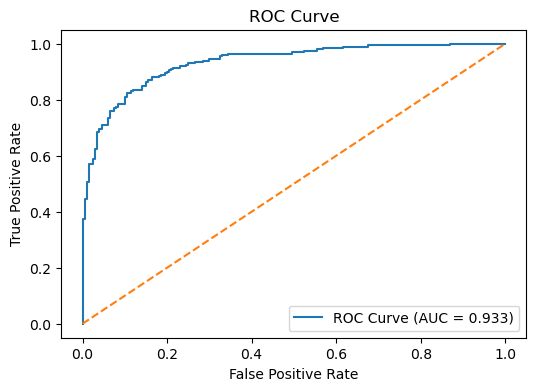

In [67]:
ln_model = LogisticRegression(max_iter = 1000, random_state = 42)
ln_model.fit(X_train_tfidf, y_train)
y_pred = ln_model.predict(X_test_tfidf)

print("Train Accuracy:", ln_model.score(X_train_tfidf, y_train))
print("Test Accuracy:", ln_model.score(X_test_tfidf, y_test))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))



# roc-auc 
y_test_bin = (y_test == 'pos').astype(int)
y_proba = ln_model.predict_proba(X_test_tfidf)[:, list(ln_model.classes_).index('pos')]

fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
auc = roc_auc_score(y_test_bin, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [70]:
for c in [0.03, 0.05, 0.07, 0.09, 0.1, 0.3, 0.5, 0.7, 0.9]:
    model = LogisticRegression(max_iter=1000, C=c, random_state=42)
    model.fit(X_train_tfidf, y_train)
    print(f"C={c}, Train: {model.score(X_train_tfidf, y_train):.4f}, Test: {model.score(X_test_tfidf, y_test):.4f}")

C=0.03, Train: 0.9006, Test: 0.8200
C=0.05, Train: 0.9056, Test: 0.8250
C=0.07, Train: 0.9062, Test: 0.8250
C=0.09, Train: 0.9062, Test: 0.8250
C=0.1, Train: 0.9062, Test: 0.8250
C=0.3, Train: 0.9337, Test: 0.8400
C=0.5, Train: 0.9437, Test: 0.8450
C=0.7, Train: 0.9494, Test: 0.8500
C=0.9, Train: 0.9600, Test: 0.8500


In [74]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LogisticRegression(max_iter=1000, C=0.7, random_state=42), X_train_tfidf, y_train, cv=5)
print(scores.mean(), scores.std())

0.85625 0.027314716729265196


Train Accuracy: 0.90625
Test Accuracy: 0.825
              precision    recall  f1-score   support

         neg       0.83      0.82      0.82       200
         pos       0.82      0.83      0.83       200

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400

[[164  36]
 [ 34 166]]


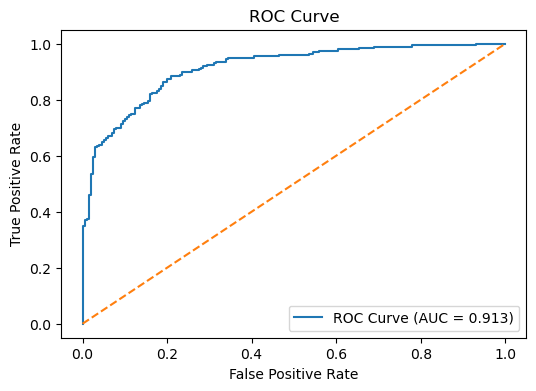

In [73]:
ln_model1 = LogisticRegression(max_iter = 1000, C= 0.07, random_state = 42)
ln_model1.fit(X_train_tfidf, y_train)
y_pred = ln_model1.predict(X_test_tfidf)

print("Train Accuracy:", ln_model1.score(X_train_tfidf, y_train))
print("Test Accuracy:", ln_model1.score(X_test_tfidf, y_test))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# roc-auc 
y_test_bin = (y_test == 'pos').astype(int)
y_proba = ln_model1.predict_proba(X_test_tfidf)[:, list(ln_model1.classes_).index('pos')]

fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
auc = roc_auc_score(y_test_bin, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#### Naive Bayes Classifier - Multinomial NB

Train accuracy: 0.925
Test Accuracy: 0.8075
              precision    recall  f1-score   support

         neg       0.79      0.83      0.81       200
         pos       0.83      0.78      0.80       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400

[[167  33]
 [ 44 156]]


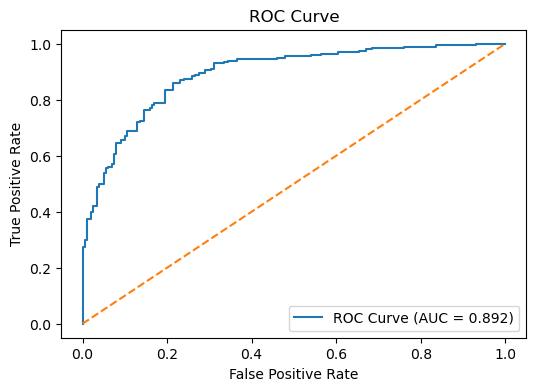

In [49]:
from sklearn.naive_bayes import MultinomialNB


nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred = nb_model.predict(X_test_tfidf)

print('Train accuracy:',nb_model.score(X_train_tfidf,y_train))
print('Test Accuracy:',nb_model.score(X_test_tfidf, y_test))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

#roc_auc
y_test_bin =  (y_test =='pos').astype(int)
y_proba = nb_model.predict_proba(X_test_tfidf)[:,list(nb_model.classes_).index('pos')]


fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
auc = roc_auc_score(y_test_bin, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### We tested Logistic Regression and Multinomial Naive Bayes. Logistic Regression (C=0.7) was chosen as the final model since it gave higher test accuracy (85% vs 80.75%) and less overfitting compared to Naive Bayes, which is reasonable given the small dataset size. Future work could explore pretrained embeddings or a larger dataset for further improvement.